# Inspect Pipeline Output
Replicates and tests the pipeline's plotting functions directly from the NetCDF output files.

In [2]:
%load_ext autoreload
%autoreload 2

import sys, os, configparser
sys.path.insert(0, "/home/kbrennan/balloon_optimizer")

import run_pipeline as rp          # all plotting/loading functions live here
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
RUN_DIR = "/net/litho/atmosdyn2/kbrennan/data/balloon/solutions/ifs_ensemble_test_20260222_12_20260224_12_20260227_084135"

cfg = configparser.ConfigParser(inline_comment_prefixes=("#",))
cfg.read(os.path.join(RUN_DIR, "params.txt"))

START_LAT = cfg.getfloat("origin", "start_lat")
START_LON = cfg.getfloat("origin", "start_lon")

# Discover which member_ subdirectories were actually produced
MEMBERS = sorted([
    d.replace("member_", "")
    for d in os.listdir(RUN_DIR)
    if d.startswith("member_") and os.path.isdir(os.path.join(RUN_DIR, d))
])

print(f"Run dir : {RUN_DIR}")
print(f"Origin  : {START_LAT}°N  {START_LON}°E")
print(f"Members : {MEMBERS}")

Run dir : /net/litho/atmosdyn2/kbrennan/data/balloon/solutions/ifs_ensemble_test_20260222_12_20260224_12_20260227_084135
Origin  : 51.963517°N  7.61565°E
Members : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50']


In [4]:
# Plotting helpers are defined in run_pipeline.py and accessed via `rp`.
#
#   rp.plot_member_from_nc(member_dir, member, start_lat, start_lon)
#       -> (fig_map, fig_pressure)  – map + pressure profiles for all k_best trajectories
#
#   rp.plot_member_by_target(member_dir, member, target_lat, target_lon, radius_km=200)
#       -> fig_pressure | None      – profiles of trajectories ending near a target point
#
#   rp.plot_probabilistic_from_nc(run_dir, members, start_lat, start_lon)
#       -> dict of figures           – fraction-reachable map, histogram, (landing-zone overlays)
print("run_pipeline version:", getattr(rp, "__version__", "n/a"))
print("Available plotting helpers:", [n for n in dir(rp) if n.startswith("plot_")])

run_pipeline version: n/a
Available plotting helpers: ['plot_member', 'plot_member_by_target', 'plot_member_from_nc', 'plot_probabilistic_from_nc']


## Per-member plots
Loop over all members, load their NetCDF output and display the trajectory map and pressure profiles.

/tmp/ipykernel_46327/2303127524.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_traj   = ds.dims["trajectory"]
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)



member_01: 30 trajectories, best = 2151 km


/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords,

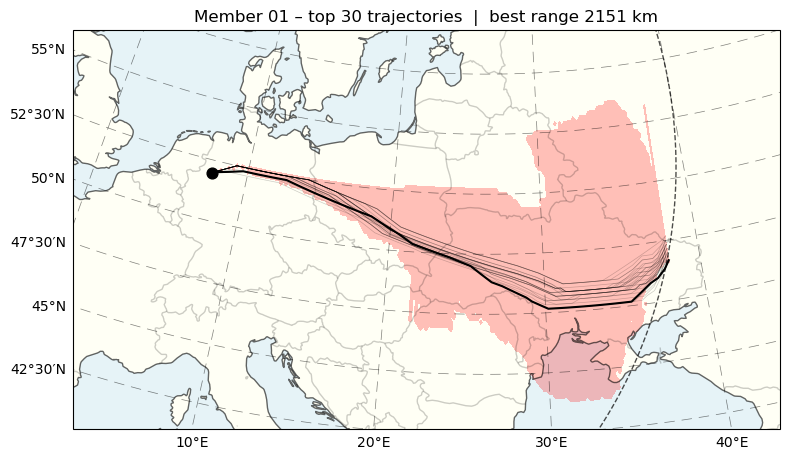

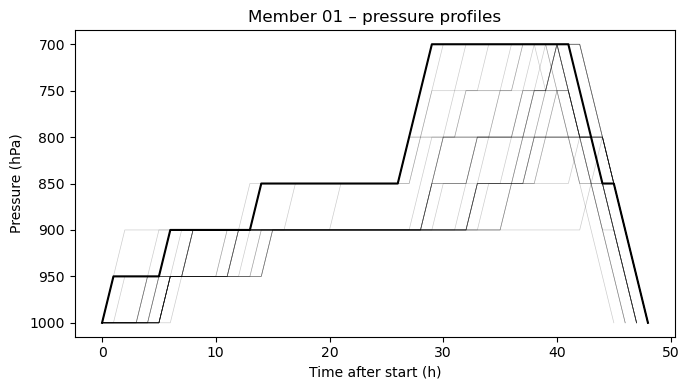

In [5]:
for member in MEMBERS[:1]:
    member_dir = os.path.join(RUN_DIR, f"member_{member}")
    traj_path  = os.path.join(member_dir, "trajectories.nc")

    if not os.path.isfile(traj_path):
        print(f"member_{member}: trajectories.nc not found – skipping"); continue

    with xr.open_dataset(traj_path, decode_times=False) as ds:
        n_traj   = ds.dims["trajectory"]
        best_km  = float(ds["distance_m"].values[0]) / 1e3
    print(f"\nmember_{member}: {n_traj} trajectories, best = {best_km:.0f} km")

    fig_map, fig_pres = rp.plot_member_from_nc(member_dir, member, START_LAT, START_LON)
    plt.show()
    plt.show()

## Trajectories ending near a target point
Calls `rp.plot_member_by_target()` to show pressure profiles for every trajectory
that lands within `radius_km` of the chosen coordinates.

In [6]:
# Edit these coordinates to match a landing zone of interest
TARGET_LAT =  37.0   # °N
TARGET_LON =  -9.0   # °E
RADIUS_KM  = 200.0

for member in MEMBERS:
    member_dir = os.path.join(RUN_DIR, f"member_{member}")
    fig = rp.plot_member_by_target(
        member_dir, member, TARGET_LAT, TARGET_LON, radius_km=RADIUS_KM
    )
    if fig is not None:
        plt.show()
    else:
        print(f"member_{member}: no trajectories within {RADIUS_KM:.0f} km of target")

member_01: no trajectories within 200 km of target
member_02: no trajectories within 200 km of target
member_03: no trajectories within 200 km of target
member_04: no trajectories within 200 km of target
member_05: no trajectories within 200 km of target
member_06: no trajectories within 200 km of target
member_07: no trajectories within 200 km of target
member_08: no trajectories within 200 km of target
member_09: no trajectories within 200 km of target
member_10: no trajectories within 200 km of target
member_11: no trajectories within 200 km of target
member_12: no trajectories within 200 km of target
member_13: no trajectories within 200 km of target
member_14: no trajectories within 200 km of target
member_15: no trajectories within 200 km of target
member_16: no trajectories within 200 km of target
member_17: no trajectories within 200 km of target
member_18: no trajectories within 200 km of target
member_19: no trajectories within 200 km of target
member_20: no trajectories with

## Probabilistic output
Load the aggregated `probabilistic.nc` and reproduce the ensemble-fraction map and max-range histogram.

In [7]:
prob_path = os.path.join(RUN_DIR, "probabilistic", "probabilistic.nc")
with xr.open_dataset(prob_path, decode_times=False) as ds_prob:
    print(ds_prob)

<xarray.Dataset> Size: 984kB
Dimensions:             (lat: 271, lon: 361, member: 50)
Coordinates:
  * lat                 (lat) float64 2kB 30.0 30.17 30.33 ... 74.67 74.83 75.0
  * lon                 (lon) float64 3kB -22.0 -21.83 -21.67 ... 37.83 38.0
  * member              (member) <U2 400B '07' '15' '05' '14' ... '48' '49' '50'
Data variables:
    reachable_fraction  (lat, lon) float64 783kB ...
    reachable_count     (lat, lon) int16 196kB ...
    max_distance_m      (member) float64 400B ...
Attributes:
    start_lat:  51.963517
    start_lon:  7.61565
    n_members:  50


/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/kbrennan/.conda/envs/kbrennan_2024/lib/python3.11/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)


=== Probabilistic Summary ===
  member 07: 2116 km
  member 15: 2132 km
  member 05: 2129 km
  member 14: 2131 km
  member 04: 2124 km
  member 13: 2160 km
  member 08: 2117 km
  member 01: 2151 km
  member 12: 2108 km
  member 06: 2145 km
  member 09: 2187 km
  member 02: 2157 km
  member 10: 2145 km
  member 03: 2206 km
  member 16: 2114 km
  member 11: 2202 km
  member 17: 2121 km
  member 18: 2178 km
  member 21: 2095 km
  member 30: 2109 km
  member 22: 2146 km
  member 20: 2165 km
  member 25: 2103 km
  member 26: 2106 km
  member 19: 2096 km
  member 32: 2183 km
  member 31: 2161 km
  member 23: 2173 km
  member 24: 2192 km
  member 27: 2177 km
  member 29: 2236 km
  member 28: 2188 km
  member 33: 2110 km
  member 36: 2144 km
  member 34: 2150 km
  member 35: 2214 km
  member 37: 2142 km
  member 39: 2157 km
  member 40: 2137 km
  member 38: 2133 km
  member 44: 2204 km
  member 47: 2173 km
  member 41: 2185 km
  member 43: 2214 km
  member 42: 2128 km
  member 46: 2128 km
  me

/home/kbrennan/balloon_optimizer/run_pipeline.py:1500: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_zones = int(ds_lz.dims["zone"])


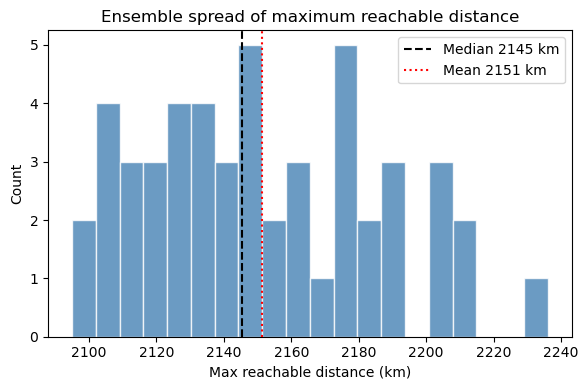

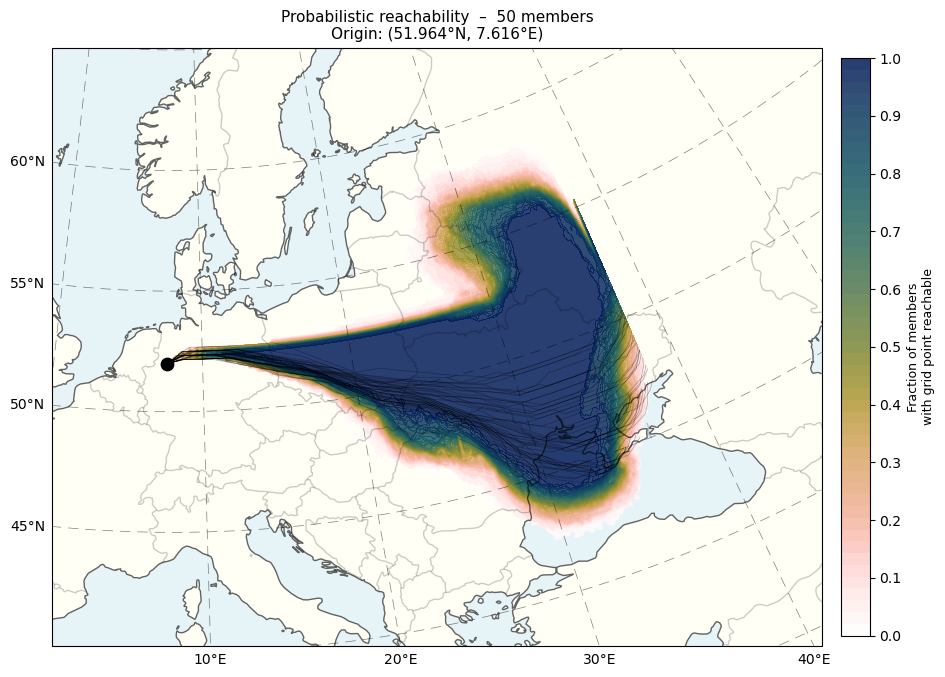

--- histogram ---


<Figure size 640x480 with 0 Axes>

In [10]:
figures = rp.plot_probabilistic_from_nc(RUN_DIR, MEMBERS, START_LAT, START_LON)

for name, fig in figures.items():
    print(f"--- {name} ---")
    plt.figure(fig.number)
    plt.show()